# mnist dataset으로 CNN 모델 작성

In [22]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# 구조 변경(차원)
print(x_train.shape)    # (60000,, 28, 28)
x_train = x_train.reshape((-1, 28, 28, 1)).astype('float32') / 255.0
x_test = x_test.reshape((-1, 28, 28, 1)).astype('float32') / 255.0
print(x_train.shape)    # (60000, 28, 28, 1)
# print(x_train[0])

# 모델 정의
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(filters=16, kernel_size=(3,3), strides=(1,1), padding='same', activation='relu'),
    tf.keras.layers.MaxPool2D(pool_size=(2, 2)),
    tf.keras.layers.Dropout(rate=0.2),

    tf.keras.layers.Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu'),
    tf.keras.layers.MaxPool2D(pool_size=(2, 2)),

    tf.keras.layers.Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu'),
    tf.keras.layers.MaxPool2D(pool_size=(2, 2)),

    tf.keras.layers.Flatten(),   #FCLayer  -> 1차원으로 축소
    tf.keras.layers.Dense(units=64, activation='relu'),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(units=32, activation='relu'),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(units=10, activation='softmax')   
])
print(model.summary())

(60000, 28, 28)
(60000, 28, 28, 1)
Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_9 (Conv2D)           (None, 28, 28, 16)        160       
                                                                 
 max_pooling2d_9 (MaxPooling  (None, 14, 14, 16)       0         
 2D)                                                             
                                                                 
 dropout_9 (Dropout)         (None, 14, 14, 16)        0         
                                                                 
 conv2d_10 (Conv2D)          (None, 14, 14, 32)        4640      
                                                                 
 max_pooling2d_10 (MaxPoolin  (None, 7, 7, 32)         0         
 g2D)                                                            
                                                                 
 conv2d_11 (Conv2D)

In [24]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
es = tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

history = model.fit(
    x_train, y_train, epochs=100, batch_size=128, validation_split=0.1, callbacks=[es], verbose=2
)


Epoch 1/100
422/422 - 2s - loss: 0.6725 - accuracy: 0.7775 - val_loss: 0.0987 - val_accuracy: 0.9713 - 2s/epoch - 4ms/step
Epoch 2/100
422/422 - 1s - loss: 0.1923 - accuracy: 0.9441 - val_loss: 0.0581 - val_accuracy: 0.9827 - 1s/epoch - 3ms/step
Epoch 3/100
422/422 - 1s - loss: 0.1388 - accuracy: 0.9600 - val_loss: 0.0455 - val_accuracy: 0.9878 - 1s/epoch - 3ms/step
Epoch 4/100
422/422 - 1s - loss: 0.1110 - accuracy: 0.9681 - val_loss: 0.0400 - val_accuracy: 0.9880 - 1s/epoch - 3ms/step
Epoch 5/100
422/422 - 1s - loss: 0.0946 - accuracy: 0.9739 - val_loss: 0.0400 - val_accuracy: 0.9875 - 1s/epoch - 3ms/step
Epoch 6/100
422/422 - 1s - loss: 0.0826 - accuracy: 0.9778 - val_loss: 0.0378 - val_accuracy: 0.9885 - 1s/epoch - 3ms/step
Epoch 7/100
422/422 - 1s - loss: 0.0717 - accuracy: 0.9806 - val_loss: 0.0292 - val_accuracy: 0.9927 - 1s/epoch - 3ms/step
Epoch 8/100
422/422 - 1s - loss: 0.0677 - accuracy: 0.9815 - val_loss: 0.0318 - val_accuracy: 0.9918 - 1s/epoch - 3ms/step
Epoch 9/100
422/

In [25]:
# 모델 평가
train_loss, train_acc = model.evaluate(x_train, y_train, verbose=0)
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f'train_loss:{train_loss:.4f}, train_acc:{train_acc:.4f}')
print(f'test_loss:{train_loss:.4f}, test_acc:{train_acc:.4f}')

# 모델 저장
save_path = 'mnist_cnn.keras'
model.save(save_path)

train_loss:0.0296, train_acc:0.9916
test_loss:0.0296, test_acc:0.9916


In [26]:
# 모델 읽기
loaded_model = tf.keras.models.load_model(save_path)
loss2, acc2 = loaded_model.evaluate(x_test, y_test, verbose=0)
print(f'loss2:{loss2:.4f}, acc2:{acc2:.4f}')

# 기존 자료 1개로 예측
idx = 0 # 원하는 값 입력
y_true = int(y_test[idx])
x_one = x_test[idx:idx + 1]     # (1, 28, 28, 1)
probs = loaded_model.predict(x_one, verbose=0)[0]   # (10, )
y_pred = int(np.argmax(probs))
print(f'실제값:{y_true}, 예측값:{y_pred}, 확률값:{np.round(probs, 3)}')

loss2:0.0346, acc2:0.9886
실제값:7, 예측값:7, 확률값:[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]


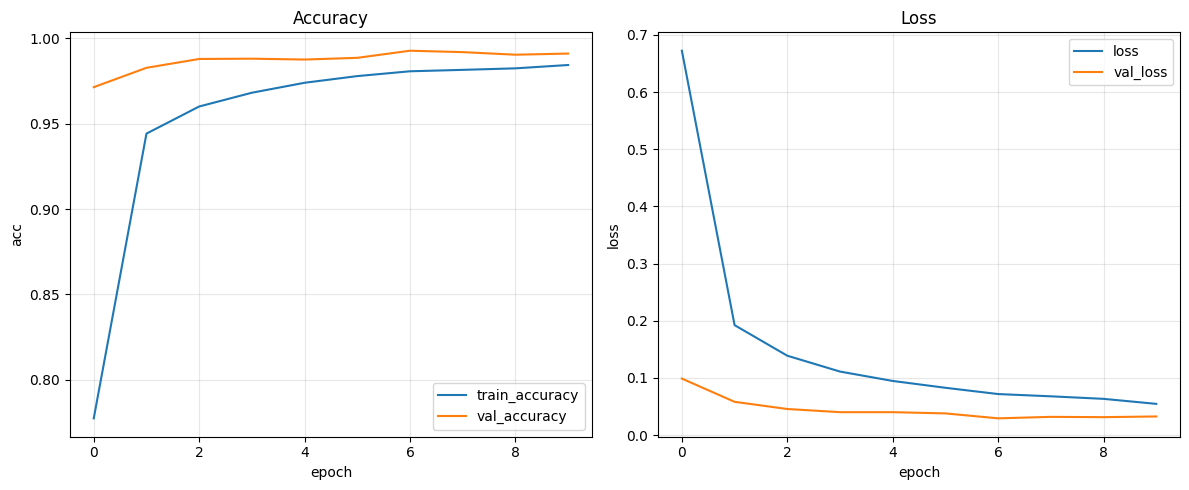

In [31]:
# 시각화: 학습 곡선
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Accuracy')
plt.xlabel('epoch')
plt.ylabel('acc')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 단일 이미지 + 예측 확률 막대 시각화

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


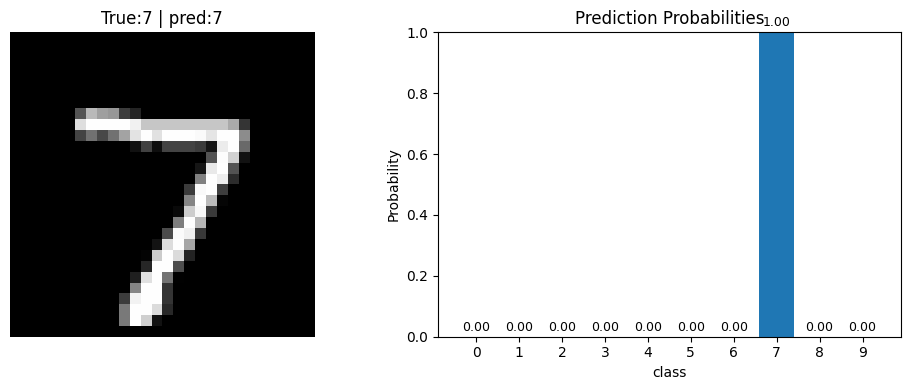

In [41]:
classes = [str(i) for i in range(10)]
print(classes)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(x_one[0].squeeze(), cmap='gray')
plt.axis('off')
plt.title(f'True:{y_true} | pred:{y_pred}')

plt.subplot(1, 2, 2)
plt.bar(classes, probs)
plt.title('Prediction Probabilities')
plt.xlabel('class')
plt.ylabel('Probability')
plt.ylim(0, 1.0)
for i, v in enumerate(probs):
    plt.text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()


# Confusion matrix

[7 2 1 ... 4 5 6]


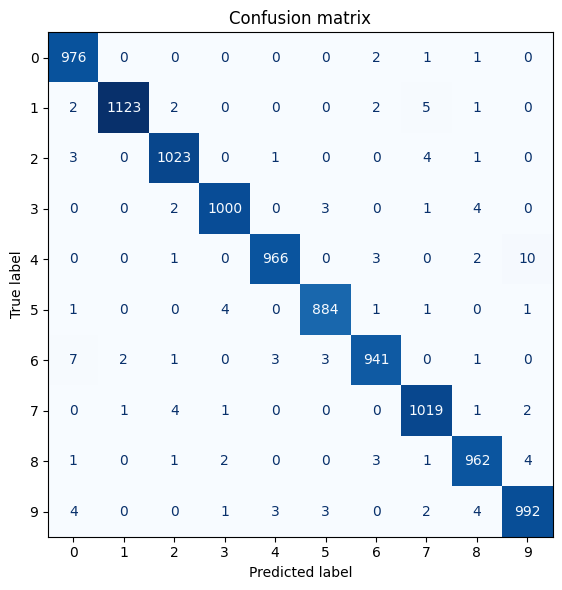

In [44]:
from tabnanny import verbose
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred_all = np.argmax(loaded_model.predict(x_test, verbose=0), axis=1)
print(y_pred_all)
cm = confusion_matrix(y_test, y_pred_all, labels=list(range(10)))
disp = ConfusionMatrixDisplay(cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)
plt.title('Confusion matrix')
plt.tight_layout()
plt.show()


# --- preprocess + predict for CNN(MNIST) ---

In [40]:
# --- preprocess + predict for CNN(MNIST) ---
from PIL import Image, ImageOps
# ImageOps : ImageOps는 Pillow(PIL) 의 유틸 모듈. 이미지에 자주 쓰는 후처리/기하 변환/톤 조정 기능들을 한 곳에 모아둔 것
import numpy as np
import tensorflow as tf

def preprocess_mnist(path, invert="auto"):
    im = Image.open(path).convert("L")

    try:
        im = ImageOps.pad(im, (28, 28), method=Image.Resampling.LANCZOS, color=255, centering=(0.5, 0.5))
    except AttributeError:
        im = ImageOps.pad(im, (28, 28), color=255, centering=(0.5, 0.5))

    img = np.asarray(im).astype("float32")  # (28, 28), 0..255

    # MNIST는 "검은 배경(0), 흰 글씨(255)". 배경이 밝으면 자동 반전
    if invert == "auto":
        if img.mean() > 127:
            img = 255.0 - img
    elif invert is True:
        img = 255.0 - img

    # 정규화 + 채널 차원 추가 → (1, 28, 28, 1)
    img = img / 255.0
    img = np.expand_dims(img, axis=(0, -1))
    return img

save_path = "mnist_cnn.keras"
mymodel = tf.keras.models.load_model(save_path)

# 내 이미지 전처리 & 예측
data = preprocess_mnist('su.png')             # shape (1, 28, 28, 1)
new_pred = mymodel.predict(data, verbose=0)   # shape (1, 10)

pred_class = int(np.argmax(new_pred, axis=1)[0])
pred_conf  = float(new_pred[0, pred_class])
print('probs  :', np.round(new_pred, 4))
print('class  :', pred_class)
print('conf   :', pred_conf)

probs  : [[0.000e+00 0.000e+00 0.000e+00 0.000e+00 9.972e-01 0.000e+00 0.000e+00
  2.000e-04 6.000e-04 1.900e-03]]
class  : 4
conf   : 0.9972177743911743
